# Groundwater Quality Risk Assessment System

## Phase 4: Irrigation Suitability Classification

### Workflow
1. Load ML-ready dataset
2. Define features & target
3. Handle rare classes + merge tiny classes
4. Drop negative-importance features
5. Re-encode y
6. Train/test split
7. SMOTEENN on training set
8. Train & cross-validate multiple models (with class_weight)
9. Model comparison
10. Hyperparameter tuning (best model)
11. Final evaluation
12. Learning curve
13. Feature importance
14. Save model & artifacts

## 1. Imports & Load Data

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN

RANDOM_STATE = 42
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [9]:
df = pd.read_csv("../data/processed/groundwater_clean_2018_2020.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (1106, 27)


,year,season,sno,district,mandal,village,lat,lon,gwl,ph,ec,tds,co3,hco3,cl,f,no3,so4,na,k,ca,mg,th,sar,rsc,irrigation_class,rsc_class
0,2018,post_monsoon,1,Adilabad,Adilabad,Adilabad,19.668300,78.524700,5.09,8.28,745,476.80,0.0,220.0,60,0.44,42.276818,46.0,49.0,4.0,48.0,38.896,279.934211,1.273328,-1.198684,C2S1,P.S.
1,2018,post_monsoon,2,Adilabad,Bazarhatnur,Bazarhatnur,19.458888,78.350833,5.10,8.29,921,589.44,0.0,230.0,80,0.56,100.659091,68.0,42.0,5.0,56.0,63.206,399.893092,0.913166,-3.397862,C3S1,P.S.
2,2018,post_monsoon,3,Adilabad,Gudihatnoor,Gudihatnoor,19.525555,78.512222,4.98,7.69,510,326.40,0.0,200.0,30,0.66,41.471545,44.0,45.0,2.0,24.0,38.896,219.934211,1.319284,-0.398684,C2S1,P.S.
3,2018,post_monsoon,4,Adilabad,Jainath,Jainath,19.730555,78.640000,5.75,8.09,422,270.08,0.0,160.0,10,0.58,10.669864,35.0,27.0,1.0,32.0,19.448,159.967105,0.928155,0.000658,C2S1,P.S.
4,2018,post_monsoon,5,Adilabad,Narnoor,Narnoor,19.495665,78.852654,2.15,8.21,2321,1485.44,0.0,300.0,340,2.56,128.843636,280.0,298.0,5.0,56.0,92.378,519.843750,5.682664,-4.396875,C4S2,P.S.


## 2. Define Features & Target

In [10]:
TARGET = "irrigation_class"

# Keep only valid compound classes (C1-4 / S1-4); drop dirty labels like OG / O.G
valid = df[TARGET].str.match(r"^C[1-4]S[1-4]$", na=False)
print(f"Dropping {(~valid).sum()} rows with invalid labels: "
      f"{df.loc[~valid, TARGET].unique().tolist()}")
df = df[valid].reset_index(drop=True)

# EC and SAR directly determine the C and S axes of the label -> exclude (circular).
# TDS is a near-perfect proxy for EC, so exclude it too.
LEAKAGE_COLS = ["ec", "sar", "tds"]

# Non-feature metadata to drop
META_COLS = ["year", "season", "sno", "district", "mandal", "village",
             "lat", "lon", "gwl", "rsc", "irrigation_class", "rsc_class"]

DROP_COLS = [c for c in (LEAKAGE_COLS + META_COLS) if c in df.columns]

# Encode the compound label
original_encoder = LabelEncoder()
y = pd.Series(original_encoder.fit_transform(df[TARGET]), name=TARGET)
X = df.drop(columns=DROP_COLS)

# Impute any remaining NaNs in ion-chemistry features (e.g. co3) by column median
X = X.fillna(X.median(numeric_only=True))

print(f"Features : {X.shape[1]}")
print(f"Samples  : {len(X)}")
print(f"Feature columns: {X.columns.tolist()}")
print("\nClass distribution:")
print(y.value_counts().sort_index())

Dropping 4 rows with invalid labels: ['OG', 'O.G']
Features : 12
Samples  : 1102
Feature columns: ['ph', 'co3', 'hco3', 'cl', 'f', 'no3', 'so4', 'na', 'k', 'ca', 'mg', 'th']

Class distribution:
irrigation_class
0       3
1     248
2       1
3     696
4      12
5       6
6       1
7      87
8      36
9       5
10      7
Name: count, dtype: int64


## 3. Handle Rare Classes + Merge Tiny Classes

**Change 1:** Instead of only dropping classes with <2 samples, we merge all classes with <6 samples into their nearest irrigation tier. This gives SMOTEENN enough samples to work with and reduces noise from near-empty classes.

Irrigation class order (severity): C1S1 < C2S1 < C2S2 < C3S1 < C3S2 < C3S3 < C3S4 < C4S1 < C4S2 < C4S3 < C4S4 < OG

In [11]:
# Class names come from the encoder fitted in the previous cell
class_counts = y.value_counts().sort_index()
print("Class counts with names:")
for code, count in class_counts.items():
    name = original_encoder.classes_[code]
    flag = " <- tiny (<6)" if count < 6 else ""
    print(f"  [{code}] {name:6s} : {count}{flag}")

Class counts with names:
  [0] C1S1   : 3 <- tiny (<6)
  [1] C2S1   : 248
  [2] C2S2   : 1 <- tiny (<6)
  [3] C3S1   : 696
  [4] C3S2   : 12
  [5] C3S3   : 6
  [6] C3S4   : 1 <- tiny (<6)
  [7] C4S1   : 87
  [8] C4S2   : 36
  [9] C4S3   : 5 <- tiny (<6)
  [10] C4S4   : 7


In [12]:
# Merge tiny classes (<6 samples) into nearest class by irrigation severity
# Inspect the print above to confirm these mappings before running
#
# Example merge logic (update based on your actual encoded values):
#   C1S1 (tiny) → C2S1  (both low hazard)
#   C3S2 (tiny) → C3S3  (same salinity tier, next sodium tier)
#   C4S1 (tiny) → C3S4  (closest by count/tier)
#   C4S3 (tiny) → C4S2  (same salinity tier)

# Map: {old_encoded_value: new_encoded_value}
# Populate this based on the cell above output
merge_map = {}
tiny_codes = class_counts[class_counts < 6].index.tolist()

for code in tiny_codes:
    name = original_encoder.classes_[code]
    # Find nearest non-tiny class by encoded value
    non_tiny = class_counts[class_counts >= 6].index.tolist()
    nearest  = min(non_tiny, key=lambda x: abs(x - code))
    merge_map[code] = nearest
    print(f"  Merging [{code}] {name} → [{nearest}] {original_encoder.classes_[nearest]}")

y = y.map(lambda val: merge_map.get(val, val))

print("\nClass distribution after merging:")
for code, count in y.value_counts().sort_index().items():
    print(f"  [{code}] {original_encoder.classes_[code]:8s} : {count}")

  Merging [0] C1S1 → [1] C2S1
  Merging [2] C2S2 → [1] C2S1
  Merging [6] C3S4 → [5] C3S3
  Merging [9] C4S3 → [8] C4S2

Class distribution after merging:
  [1] C2S1     : 252
  [3] C3S1     : 696
  [4] C3S2     : 12
  [5] C3S3     : 7
  [7] C4S1     : 87
  [8] C4S2     : 41
  [10] C4S4     : 7


## 4. Drop Negative-Importance Features

**Change 3:** `F` and `pH` showed negative permutation importance in the previous run — they slightly hurt the model. Dropping them reduces noise.

In [13]:
# All remaining columns are ion-chemistry features we intend to keep.
# (EC / SAR / TDS were already excluded as label-determining leakage.)
feature_names = X.columns.tolist()
print(f"Final feature count: {len(feature_names)}")
print(feature_names)

Final feature count: 12
['ph', 'co3', 'hco3', 'cl', 'f', 'no3', 'so4', 'na', 'k', 'ca', 'mg', 'th']


## 5. Re-encode y

After merging, encoded values may not be consecutive. Re-encode to ensure XGBoost compatibility.

In [14]:
y_reencoder = LabelEncoder()
y = pd.Series(y_reencoder.fit_transform(y), name=TARGET)

# Map new codes back to original class names for reference
class_names = original_encoder.classes_[y_reencoder.classes_]

print("Final class mapping (new code → original name):")
for new_code, orig_name in enumerate(class_names):
    count = (y == new_code).sum()
    print(f"  {new_code} → {orig_name:8s} ({count} samples)")

# Save updated encoder
os.makedirs("../models/irrigation", exist_ok=True)
joblib.dump(y_reencoder, "../models/irrigation/label_encoder.pkl")
print("\nUpdated label encoder saved.")

Final class mapping (new code → original name):
  0 → C2S1     (252 samples)
  1 → C3S1     (696 samples)
  2 → C3S2     (12 samples)
  3 → C3S3     (7 samples)
  4 → C4S1     (87 samples)
  5 → C4S2     (41 samples)
  6 → C4S4     (7 samples)

Updated label encoder saved.


## 6. Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (881, 12)
Test  : (221, 12)


## 7. SMOTEENN on Training Set Only

**Change 4:** Using **SMOTEENN** instead of plain SMOTE. SMOTEENN oversamples minority classes AND removes noisy borderline majority samples — producing cleaner decision boundaries than SMOTE alone.

> ⚠️ Applied only to training data — test set stays untouched.

In [16]:
print("Class distribution before SMOTEENN:")
print(y_train.value_counts().sort_index())

smoteenn = SMOTEENN(random_state=RANDOM_STATE)
X_train_res, y_train_res = smoteenn.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTEENN:")
print(pd.Series(y_train_res).value_counts().sort_index())
print(f"\nResampled train size: {X_train_res.shape}")

Class distribution before SMOTEENN:
irrigation_class
0    201
1    556
2     10
3      6
4     69
5     33
6      6
Name: count, dtype: int64

Class distribution after SMOTEENN:
irrigation_class
0    540
1    452
2    556
3    556
4    545
5    537
6    556
Name: count, dtype: int64

Resampled train size: (3742, 12)


## 8. Train & Cross-Validate Multiple Models

**Change 2:** Added `class_weight='balanced'` to all supported models (LR, DT, RF, SVM). This penalizes misclassification of minority classes more heavily, complementing SMOTEENN.

Using **Stratified 5-Fold** cross-validation on the resampled training set.

In [17]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Decision Tree"       : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight="balanced"),
    "XGBoost"             : XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE),
    "KNN"                 : KNeighborsClassifier(),
    "SVM"                 : SVC(random_state=RANDOM_STATE, class_weight="balanced")
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring="f1_macro")

    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    acc      = accuracy_score(y_test, y_pred)
    macro_p  = precision_score(y_test, y_pred, average="macro", zero_division=0)
    macro_r  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model"     : name,
        "Accuracy"  : round(acc, 4),
        "Precision" : round(macro_p, 4),
        "Recall"    : round(macro_r, 4),
        "Macro F1"  : round(macro_f1, 4),
        "CV Mean"   : round(cv_scores.mean(), 4),
        "CV Std"    : round(cv_scores.std(), 4),
    })

    print(f"{name:22s} | Acc={acc:.4f} | Macro F1={macro_f1:.4f} | CV={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Logistic Regression    | Acc=0.8416 | Macro F1=0.4190 | CV=0.9295 ± 0.0073
Decision Tree          | Acc=0.8190 | Macro F1=0.5581 | CV=0.9789 ± 0.0055
Random Forest          | Acc=0.8778 | Macro F1=0.7131 | CV=0.9915 ± 0.0032
XGBoost                | Acc=0.8778 | Macro F1=0.7041 | CV=0.9910 ± 0.0030
KNN                    | Acc=0.8281 | Macro F1=0.4505 | CV=0.9954 ± 0.0018
SVM                    | Acc=0.8371 | Macro F1=0.4485 | CV=0.9568 ± 0.0079


## 9. Model Comparison Table

In [18]:
results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,Macro F1,CV Mean,CV Std
0,Random Forest,0.8778,0.6763,0.7788,0.7131,0.9915,0.0032
1,XGBoost,0.8778,0.6599,0.7806,0.7041,0.9910,0.0030
2,Decision Tree,0.8190,0.5599,0.5801,0.5581,0.9789,0.0055
3,KNN,0.8281,0.4309,0.5143,0.4505,0.9954,0.0018
4,SVM,0.8371,0.4336,0.4709,0.4485,0.9568,0.0079
5,Logistic Regression,0.8416,0.4074,0.4364,0.4190,0.9295,0.0073


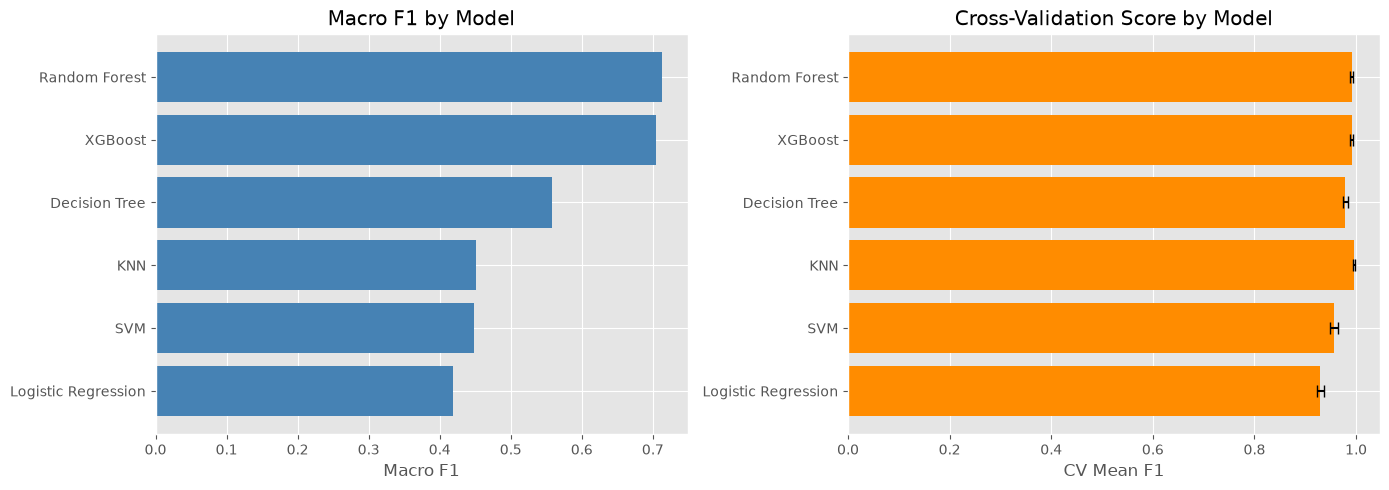

Saved: ../docs/report/irrigation_model_comparison.csv


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df["Model"], results_df["Macro F1"], color="steelblue")
axes[0].set_xlabel("Macro F1")
axes[0].set_title("Macro F1 by Model")
axes[0].invert_yaxis()

axes[1].barh(results_df["Model"], results_df["CV Mean"], xerr=results_df["CV Std"], color="darkorange", capsize=4)
axes[1].set_xlabel("CV Mean F1")
axes[1].set_title("Cross-Validation Score by Model")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

os.makedirs("../docs/report", exist_ok=True)
results_df.to_csv("../docs/report/irrigation_model_comparison.csv", index=False)
print("Saved: ../docs/report/irrigation_model_comparison.csv")

## 10. Hyperparameter Tuning (Best Model)

Tuning applied only to the top-performing model based on Macro F1.

In [20]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

param_grids = {
    "Logistic Regression": {
        "C"      : [0.01, 0.1, 1, 10, 100],
        "solver" : ["lbfgs", "saga"],
        "penalty": ["l2"]
    },
    "Decision Tree": {
        "max_depth"         : [None, 5, 10, 20],
        "min_samples_split" : [2, 5, 10],
        "min_samples_leaf"  : [1, 2, 4],
        "criterion"         : ["gini", "entropy"]
    },
    "Random Forest": {
        "n_estimators"      : [100, 200, 300],
        "max_depth"         : [None, 10, 20, 30],
        "min_samples_split" : [2, 5, 10],
        "min_samples_leaf"  : [1, 2, 4],
        "max_features"      : ["sqrt", "log2"]
    },
    "XGBoost": {
        "n_estimators"     : [100, 200, 300],
        "max_depth"        : [3, 5, 7, 10],
        "learning_rate"    : [0.01, 0.05, 0.1, 0.2],
        "subsample"        : [0.7, 0.8, 1.0],
        "colsample_bytree" : [0.7, 0.8, 1.0]
    },
    "KNN": {
        "n_neighbors" : [3, 5, 7, 10, 15],
        "weights"     : ["uniform", "distance"],
        "metric"      : ["euclidean", "manhattan"]
    },
    "SVM": {
        "C"      : [0.1, 1, 10, 100],
        "kernel" : ["rbf", "linear"],
        "gamma"  : ["scale", "auto"]
    }
}

base_model = models[best_model_name]
param_grid = param_grids[best_model_name]

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=30,
    cv=cv,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_res, y_train_res)

best_model = search.best_estimator_

print(f"\nBest params : {search.best_params_}")
print(f"Best CV F1  : {search.best_score_:.4f}")

Best model: Random Forest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best CV F1  : 0.9921


## 11. Final Evaluation on Test Set

In [21]:
y_pred_final = best_model.predict(X_test)

final_acc  = accuracy_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final, average="macro", zero_division=0)
final_rec  = recall_score(y_test, y_pred_final, average="macro", zero_division=0)
final_f1   = f1_score(y_test, y_pred_final, average="macro", zero_division=0)

print("=== Final Model Performance ===")
print(f"Model     : {best_model_name} (tuned)")
print(f"Accuracy  : {final_acc:.4f}")
print(f"Precision : {final_prec:.4f}")
print(f"Recall    : {final_rec:.4f}")
print(f"Macro F1  : {final_f1:.4f}")

=== Final Model Performance ===
Model     : Random Forest (tuned)
Accuracy  : 0.8824
Precision : 0.6784
Recall    : 0.7798
Macro F1  : 0.7149


In [22]:
report_dict = classification_report(
    y_test,
    y_pred_final,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
print(classification_report(y_test, y_pred_final, target_names=class_names, zero_division=0))

report_df.to_csv("../docs/report/irrigation_classification_report.csv")
print("Saved: ../docs/report/irrigation_classification_report.csv")

              precision    recall  f1-score   support

        C2S1       0.84      0.94      0.89        51
        C3S1       0.96      0.88      0.92       140
        C3S2       0.00      0.00      0.00         2
        C3S3       0.50      1.00      0.67         1
        C4S1       0.70      0.89      0.78        18
        C4S2       0.75      0.75      0.75         8
        C4S4       1.00      1.00      1.00         1

    accuracy                           0.88       221
   macro avg       0.68      0.78      0.71       221
weighted avg       0.89      0.88      0.88       221

Saved: ../docs/report/irrigation_classification_report.csv


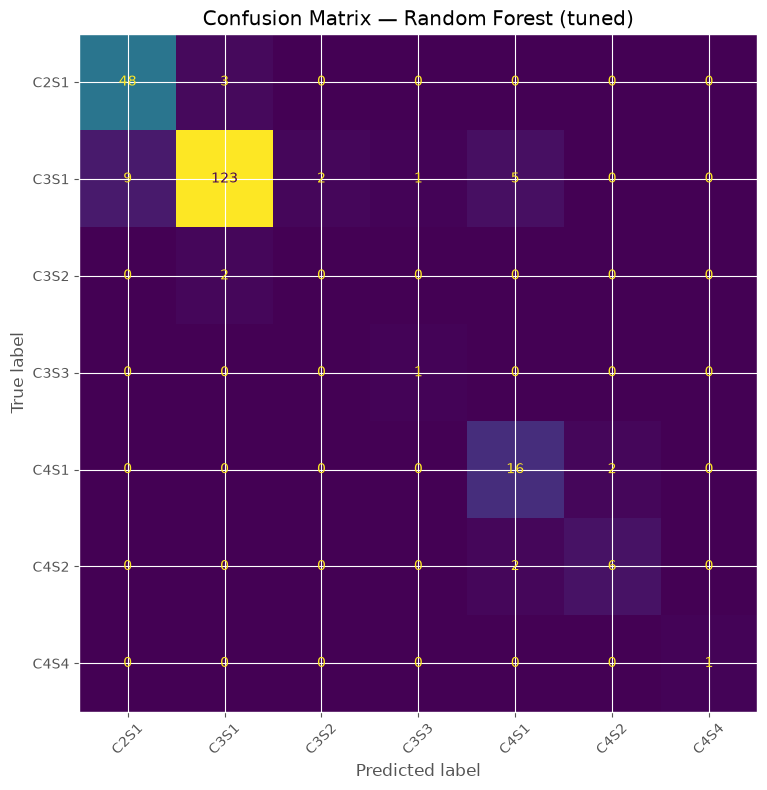

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=class_names,
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

ax.set_title(f"Confusion Matrix — {best_model_name} (tuned)")
plt.tight_layout()
plt.show()

## 12. Learning Curve

- Training score ≈ Validation score (low) → **High bias** — model too simple
- Training score >> Validation score → **High variance** — model overfitting

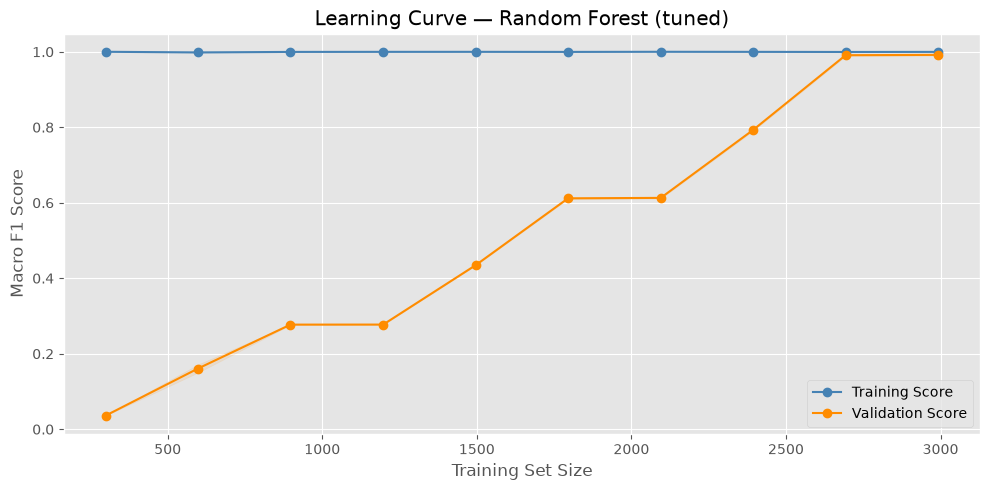

In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_res, y_train_res,
    cv=cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, "o-", color="steelblue", label="Training Score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="steelblue")
plt.plot(train_sizes, val_mean, "o-", color="darkorange", label="Validation Score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="darkorange")

plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title(f"Learning Curve — {best_model_name} (tuned)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 13. Feature Importance

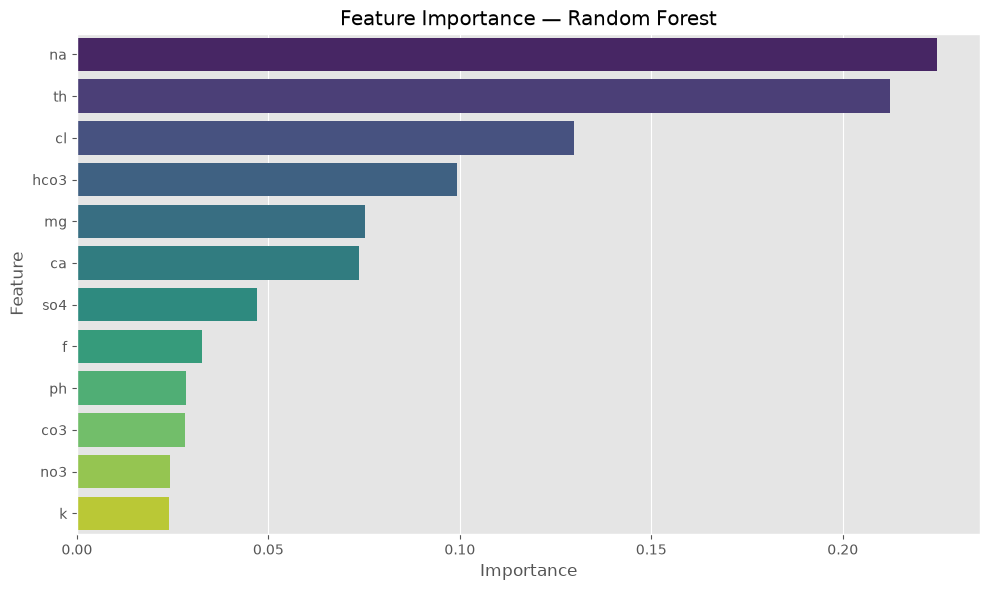

 Rank Feature  Importance
    1      na    0.224603
    2      th    0.212455
    3      cl    0.129880
    4    hco3    0.099333
    5      mg    0.075309
    6      ca    0.073653
    7     so4    0.046973
    8       f    0.032739
    9      ph    0.028475
   10     co3    0.028270
   11     no3    0.024396
   12       k    0.023915

Saved: ../docs/report/irrigation_feature_importance.csv


In [25]:
tree_based = ["Random Forest", "Decision Tree", "XGBoost"]

if best_model_name in tree_based:
    importances = best_model.feature_importances_
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        best_model, X_test, y_test,
        scoring="f1_macro",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    importances = perm.importances_mean

fi_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Importance" : importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)
fi_df.insert(0, "Rank", fi_df.index + 1)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x="Importance", y="Feature", palette="viridis")
plt.title(f"Feature Importance — {best_model_name}")
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

fi_df.to_csv("../docs/report/irrigation_feature_importance.csv", index=False)
print("\nSaved: ../docs/report/irrigation_feature_importance.csv")

## 14. Save Model & Artifacts

In [19]:
model_dir = "../models/irrigation"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(best_model,    f"{model_dir}/irrigation_model.pkl")
joblib.dump(y_reencoder,   f"{model_dir}/label_encoder.pkl")
joblib.dump(feature_names, f"{model_dir}/feature_names.pkl")

print("Saved model artifacts:")
for f in sorted(os.listdir(model_dir)):
    print(f"  {model_dir}/{f}")

print()
print(f"Final model : {best_model_name} (tuned)")
print(f"Accuracy    : {final_acc:.4f}")
print(f"Macro F1    : {final_f1:.4f}")

Saved model artifacts:
  ../models/irrigation/feature_names.pkl
  ../models/irrigation/irrigation_model.pkl
  ../models/irrigation/label_encoder.pkl

Final model : Random Forest (tuned)
Accuracy    : 0.8733
Macro F1    : 0.6179
